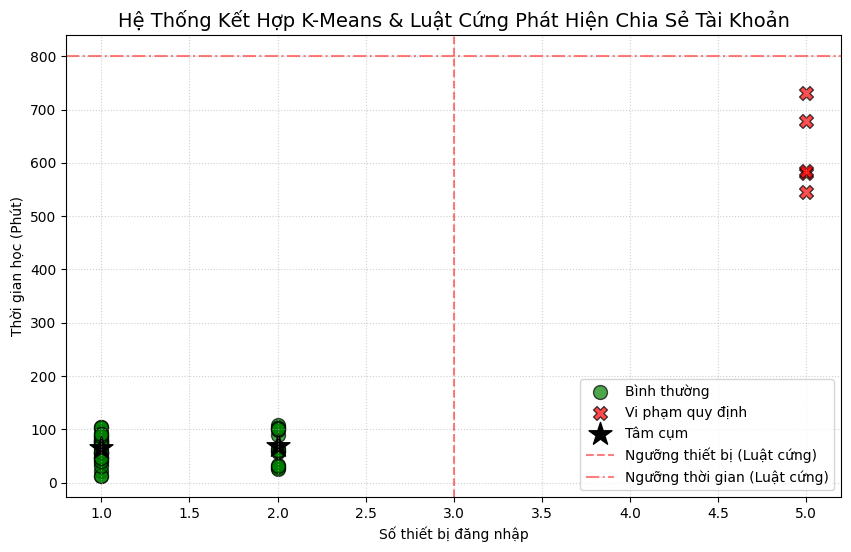


=== DANH SÁCH TÀI KHOẢN CẦN XỬ LÝ ===
    id              name  device_count  watch_time        Trang_Thai  \
9   20   Hoc Vien Test 4             5         731  Vi phạm quy định   
19  30  Hoc Vien Test 14             5         679  Vi phạm quy định   
29  40  Hoc Vien Test 24             5         546  Vi phạm quy định   
39  50  Hoc Vien Test 34             5         580  Vi phạm quy định   
49  60  Hoc Vien Test 44             5         585  Vi phạm quy định   

    Khoang_Cach  
9           NaN  
19          NaN  
29          NaN  
39          NaN  
49          NaN  


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine

# ==========================================
# 1. KẾT NỐI DB VÀ LẤY DỮ LIỆU
# ==========================================
db_connection_str = 'mysql+mysqlconnector://root:@localhost/elearning'
engine = create_engine(db_connection_str)

query = "SELECT id, name, device_count, watch_time FROM users WHERE role = 'user'"
df = pd.read_sql(query, engine)

# ==========================================
# 2. TẦNG 1: BỘ LỌC CỨNG (QUY ĐỊNH NGHIỆP VỤ)
# ==========================================
MAX_DEVICES = 3
MAX_WATCH_TIME = 800 

df['Trang_Thai'] = 'Bình thường'
df.loc[(df['device_count'] > MAX_DEVICES) | (df['watch_time'] > MAX_WATCH_TIME), 'Trang_Thai'] = 'Vi phạm quy định'

# ==========================================
# 3. TẦNG 2: BỘ LỌC MỀM (K-MEANS)
# ==========================================
df_ml = df[df['Trang_Thai'] == 'Bình thường'].copy()
df['Khoang_Cach'] = np.nan

# Kiểm tra xem có đủ dữ liệu để chạy K-Means không (Cần ít nhất 2 user bình thường)
if len(df_ml) >= 2:
    features = ['device_count', 'watch_time']
    scaler = StandardScaler()
    ml_scaled = scaler.fit_transform(df_ml[features])

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(ml_scaled)

    distances = np.min(kmeans.transform(ml_scaled), axis=1)
    df_ml['Khoang_Cach'] = distances

    NGUONG_KMEANS = 2.0
    nghi_ngo_idx = df_ml[df_ml['Khoang_Cach'] > NGUONG_KMEANS].index
    df.loc[nghi_ngo_idx, 'Trang_Thai'] = 'Nghi ngờ (K-Means phát hiện)'
    df.loc[df_ml.index, 'Khoang_Cach'] = distances
else:
    print("⚠️ CẢNH BÁO: Không đủ dữ liệu người dùng bình thường để chạy thuật toán K-Means (Cần >= 2). Chỉ áp dụng bộ lọc cứng.")

# ==========================================
# 4. TRỰC QUAN HÓA KẾT QUẢ
# ==========================================
plt.figure(figsize=(10, 6))

colors = {'Bình thường': 'green', 'Nghi ngờ (K-Means phát hiện)': 'orange', 'Vi phạm quy định': 'red'}
markers = {'Bình thường': 'o', 'Nghi ngờ (K-Means phát hiện)': 'D', 'Vi phạm quy định': 'X'}

for status in df['Trang_Thai'].unique():
    subset = df[df['Trang_Thai'] == status]
    plt.scatter(
        subset['device_count'], subset['watch_time'], 
        c=colors.get(status, 'blue'), marker=markers.get(status, 'o'), 
        label=status, s=100, alpha=0.7, edgecolor='black'
    )

# Chỉ vẽ tâm cụm nếu K-Means thực sự được chạy
if len(df_ml) >= 2:
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)
    plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='*', s=300, label='Tâm cụm')

plt.axvline(x=MAX_DEVICES, color='red', linestyle='--', alpha=0.5, label='Ngưỡng thiết bị (Luật cứng)')
plt.axhline(y=MAX_WATCH_TIME, color='red', linestyle='-.', alpha=0.5, label='Ngưỡng thời gian (Luật cứng)')

plt.title('Hệ Thống Kết Hợp K-Means & Luật Cứng Phát Hiện Chia Sẻ Tài Khoản', fontsize=14)
plt.xlabel('Số thiết bị đăng nhập')
plt.ylabel('Thời gian học (Phút)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 5. XUẤT DANH SÁCH XỬ LÝ
# ==========================================
print("\n=== DANH SÁCH TÀI KHOẢN CẦN XỬ LÝ ===")
print(df[df['Trang_Thai'] != 'Bình thường'][['id', 'name', 'device_count', 'watch_time', 'Trang_Thai', 'Khoang_Cach']])